# Winter wheat yield — TorchCrop against CyBench

**What this notebook does.** It aggregates the 10 km TorchCrop winter-wheat
yield simulation to national averages, compares them with the CyBench
sub-national yield statistics aggregated the same way, and reports RMSE, MAE,
Bias, MAPE, R² and Pearson r per country and pooled.

**Scope.** EU-27 and Schengen, excluding Ukraine and Russia. CyBench publishes
wheat for 23 of those 31 countries; the rest are listed in §1 and dropped.

**Three conventions worth knowing before reading any number:**

1. **Error is `simulated − observed`.** A negative bias means the model is low.
2. **No moisture conversion is applied.** TorchCrop's LINTUL-5 reports grain
   **dry matter**; CyBench reports the national statistics at market moisture
   (~13.5 % for wheat). Both sides are compared as published, so a systematic
   offset of roughly that size is expected on top of any model error. To put
   both on dry matter instead, call `aggregate.to_dry_matter` on the
   observations — everything downstream is unchanged.
3. **The simulated national mean is an unweighted mean of cropland cells.** The
   SIMPLACE export carries no per-cell wheat area, so no weight can be applied
   without inventing one. The observed national mean *is* area-weighted, by
   `harvest_area`, wherever enough regions report it.

All reusable code is in [`utils/`](utils/); this notebook is the workflow only.

## 0. Setup

In [1]:
import logging
import sys
from pathlib import Path

# The notebooks live beside utils/, so they import it without installation.
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd

from utils import aggregate, config, cybench, doy, metrics, plots, regions, torchcrop
from utils.style import use_style

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s",
                    force=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

PALETTE = use_style("light")
config.ensure_output_dirs()

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 140)

print(f"TorchCrop run : {config.TORCHCROP_RUN_DIR}")
print(f"CyBench root  : {config.CYBENCH_ROOT}")
print(f"Outputs       : {config.OUTPUT_DIR}")

TorchCrop run : /data01/FDS/muduchuru/Data/SIMPLACE/torchcrop/winter_wheat_2000_2024
CyBench root  : /data01/FDS/muduchuru/Data/Agri/cybench
Outputs       : /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs


## 1. Scope — which countries are evaluable

A country needs a CyBench yield file *and* CyBench polygons: the file supplies
the reference, the polygons decide which 10 km cells belong to it.

In [2]:
COUNTRIES = config.available_countries()

scope = pd.DataFrame({
    "code": list(config.TARGET_COUNTRIES),
    "name": [config.COUNTRY_NAMES.get(c, c) for c in config.TARGET_COUNTRIES],
    "eu27": [c in config.EU27 for c in config.TARGET_COUNTRIES],
    "schengen_non_eu": [c in config.SCHENGEN_NON_EU for c in config.TARGET_COUNTRIES],
    "in_cybench": [c in COUNTRIES for c in config.TARGET_COUNTRIES],
}).set_index("code")

print(f"{len(COUNTRIES)} of {len(config.TARGET_COUNTRIES)} target countries are evaluable")
print("missing:", ", ".join(scope.index[~scope["in_cybench"]]))
scope

23 of 31 target countries are evaluable
missing: CH, CY, IS, LI, LU, MT, NO, SI


,name,eu27,schengen_non_eu,in_cybench
code,,,,
AT,Austria,True,False,True
BE,Belgium,True,False,True
BG,Bulgaria,True,False,True
CH,Switzerland,False,True,False
CY,Cyprus,True,False,False
CZ,Czechia,True,False,True
DE,Germany,True,False,True
DK,Denmark,True,False,True
EE,Estonia,True,False,True


## 2. Load the TorchCrop simulation

One row per (cell, season). `year` is the **harvest** year — winter wheat is
sown in the preceding autumn.

In [3]:
sim = torchcrop.load_simulation(columns=[
    "SimplaceID", "year", "lon", "lat", "yield_t_ha", "biomass_g_m2",
    "max_lai", "days_to_maturity", "tranrf_mean", "nni_mean",
    "heat_stress_factor", "n_applied_g_m2", "irri",
])

print(f"{len(sim):,} cell-seasons, {sim['SimplaceID'].nunique():,} cells, "
      f"{sim['year'].min()}-{sim['year'].max()}")
sim[["yield_t_ha", "biomass_g_m2", "max_lai", "days_to_maturity"]].describe().T

INFO utils.torchcrop: read torchcrop_europe.parquet: 1717125 rows, 13 columns


WARNING utils.torchcrop: 70 of 1717125 rows (0.00%) never reached maturity; their dates are NaN


1,717,125 cell-seasons, 68,685 cells, 2000-2024


,count,mean,std,min,25%,50%,75%,max
yield_t_ha,1717125.0,3.351836,3.198105,0.000000,0.353908,2.368610,5.956079,12.096510
biomass_g_m2,1717125.0,514.749817,492.794800,0.876136,58.994297,349.113159,923.133057,1804.506592
max_lai,1717125.0,2.368199,2.095580,0.144690,0.557704,1.610968,4.014193,7.684073
days_to_maturity,1717055.0,263.230774,44.405205,82.000000,243.000000,272.000000,295.000000,486.000000


## 3. Assign each 10 km cell to a country

The national footprints are the CyBench administrative polygons dissolved per
country, so both sides of the comparison cover the same ground. Cells outside
that footprint — the UK, Norway, Switzerland, the western Balkans, North
Africa — are dropped.

In [4]:
cells = torchcrop.simulation_cells(sim)
cells = regions.assign_cells_to_countries(
    cells, COUNTRIES, cache=regions.default_cache_path(len(COUNTRIES))
)

sim = sim.merge(cells[["SimplaceID", "country", "snapped"]], on="SimplaceID", how="left")
scoped = sim[sim["country"].notna()].copy()

print(f"{cells['country'].notna().sum():,} of {len(cells):,} cells inside the "
      f"CyBench footprint ({cells['snapped'].sum():,} matched by the {config.SNAP_KM} km snap)")
print(f"{len(scoped):,} of {len(sim):,} simulated cell-seasons kept")

cells_per_country = (
    cells.dropna(subset=["country"]).groupby("country").size().rename("cells").to_frame()
)
cells_per_country["share_%"] = (
    100 * cells_per_country["cells"] / cells_per_country["cells"].sum()
).round(1)
cells_per_country.T

INFO utils.torchcrop: 68685 unique cells


INFO utils.regions: cell-to-country map read from /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/cache/cell_country_n23_snap5km.parquet


30,406 of 68,685 cells inside the CyBench footprint (779 matched by the 5.0 km snap)
760,150 of 1,717,125 simulated cell-seasons kept


country,AT,BE,BG,CZ,DE,DK,EE,EL,ES,FI,...,IE,IT,LT,LV,NL,PL,PT,RO,SE,SK
cells,398.0,378.0,978.0,826.0,4297.0,729.0,471.0,602.0,3258.0,120.0,...,279.0,1710.0,861.0,757.0,424.0,3880.0,376.0,2025.0,778.0,465.0
share_%,1.3,1.2,3.2,2.7,14.1,2.4,1.5,2.0,10.7,0.4,...,0.9,5.6,2.8,2.5,1.4,12.8,1.2,6.7,2.6,1.5


## 4. Aggregate the simulation to national means

In [5]:
sim_country = aggregate.aggregate_simulated(scoped, {"yield_t_ha": False})
sim_country.head()

INFO utils.aggregate: simulated: 575 country-groups, 120-5300 cells each


,country,year,yield_t_ha,sim_method,n_cells
0,AT,2000,3.152691,unweighted,398
1,AT,2001,2.558921,unweighted,398
2,AT,2002,2.931181,unweighted,398
3,AT,2003,3.301432,unweighted,398
4,AT,2004,3.579333,unweighted,398


## 5. Load and aggregate the CyBench observations

Weighted by `harvest_area` wherever at least half a country's regions report
one, which makes the national value `Σ production / Σ area` rather than the
mean of regional yields. Where it does not, the aggregation falls back to the
unweighted mean and records that in `obs_method` — Germany reports no area for
three quarters of its rows.

In [6]:
obs = cybench.load_yield(COUNTRIES)
obs_country = aggregate.aggregate_observed_yield(obs)

print(obs_country["obs_method"].value_counts().to_string())
obs_country.head()

INFO utils.cybench: dropped 28 rows with a missing or non-positive yield


INFO utils.cybench: observed yields: 24735 rows, 23 countries, 1979-2021, 54% area-weighted


INFO utils.aggregate: observed yields: 485 country-years, 93% area-weighted


obs_method
weighted      453
unweighted     32


,country,year,obs_yield,obs_method,n_regions
0,AT,1995,5.108492,weighted,3
1,AT,1996,5.000767,weighted,3
2,AT,1997,5.056469,weighted,3
3,AT,1998,4.967679,weighted,7
4,AT,1999,5.465992,weighted,3


## 6. Pair the two sides

An inner join on `(country, year)`. What it drops is logged: simulated years
CyBench does not cover (2021–2024 for most countries) and observed years before
the run starts (pre-2000).

In [7]:
paired = aggregate.pair_observations(sim_country, obs_country, ["country", "year"])
paired["residual"] = paired["yield_t_ha"] - paired["obs_yield"]

coverage = (
    paired.groupby("country")
    .agg(n_years=("year", "size"), first=("year", "min"), last=("year", "max"),
         cells=("n_cells", "median"), regions=("n_regions", "median"))
    .sort_values("n_years")
)
print(f"{len(paired)} paired country-years across {paired['country'].nunique()} countries")
coverage.T

INFO utils.aggregate: paired 412 rows; 163 simulated-only and 73 observed-only dropped


412 paired country-years across 23 countries


country,SK,IE,BG,HR,DK,EE,PL,HU,LV,EL,...,AT,BE,CZ,PT,LT,FI,NL,SE,RO,DE
n_years,2.0,5.0,10.0,13.0,15.0,17.0,18.0,19.0,19.0,20.0,...,21.0,21.0,21.0,21.0,21.0,21.0,21.0,21.0,21.0,22.0
first,2017.0,2010.0,2010.0,2008.0,2006.0,2004.0,2003.0,2002.0,2000.0,2000.0,...,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0
last,2018.0,2020.0,2020.0,2020.0,2020.0,2020.0,2020.0,2020.0,2018.0,2019.0,...,2020.0,2020.0,2020.0,2020.0,2020.0,2020.0,2020.0,2020.0,2020.0,2021.0
cells,465.0,279.0,978.0,385.0,729.0,471.0,3880.0,1109.0,757.0,602.0,...,398.0,378.0,826.0,376.0,861.0,120.0,424.0,778.0,2025.0,4297.0
regions,5.0,3.0,6.0,2.0,11.0,5.0,17.0,18.0,5.0,44.0,...,8.0,11.0,14.0,6.0,10.0,9.0,12.0,16.0,21.0,341.5


## 7. Metrics

`R²` is the coefficient of determination `1 − SS_res/SS_tot`, **not** the square
of Pearson r — it goes negative when the simulation predicts worse than the
observed mean, which is the informative case for a process model carrying a
systematic offset. Pearson r is reported separately, so a country whose
interannual pattern is right but whose level is wrong is still visible.

In [8]:
pooled = metrics.yield_metrics(paired["obs_yield"], paired["yield_t_ha"])
print("Pooled over every country-year:")
for key in metrics.YIELD_METRIC_ORDER:
    print(f"  {metrics.METRIC_LABELS[key]:>16s}  {pooled[key]:>8.2f}")

Pooled over every country-year:
                 n    412.00
     Observed mean      5.08
    Simulated mean      2.59
              Bias     -2.49
               MAE      3.16
              RMSE      4.07
          MAPE (%)     56.97
                R²     -3.01
         Pearson r     -0.40


In [9]:
by_country = metrics.metrics_by_group(paired, "obs_yield", "yield_t_ha")
ranked = metrics.rank_countries(by_country, by="rmse")

ranked.drop(columns=["sparse", "pearson_p"]).to_csv(
    config.TABLE_DIR / "yield_metrics_by_country.csv", float_format="%.3f"
)
plots.metric_table(
    ranked, ("rank", *metrics.YIELD_METRIC_ORDER),
    caption="Country yield skill, ranked by RMSE (best first). "
            "Bias and R² are in t/ha and dimensionless; countries with fewer "
            "than three paired years are listed last, unranked.",
)

,rank,n,Observed mean,Simulated mean,Bias,MAE,RMSE,MAPE (%),R²,Pearson r
Portugal (PT),1.00,21,1.83,1.86,0.03,0.71,0.84,41.30,-1.33,0.13
Romania (RO),2.00,21,3.29,2.58,-0.72,1.04,1.38,29.16,-1.80,-0.05
Poland (PL),3.00,18,4.27,3.59,-0.68,1.27,1.54,30.02,-8.75,-0.68
Hungary (HU),4.00,19,4.51,3.20,-1.31,1.36,1.59,28.61,-2.82,0.24
Latvia (LV),5.00,19,3.54,4.25,0.70,1.32,1.59,40.52,-5.11,-0.24
Czechia (CZ),6.00,21,5.33,4.34,-0.98,1.37,1.73,25.10,-4.57,-0.28
Lithuania (LT),7.00,21,4.01,4.63,0.62,1.46,1.76,39.87,-5.01,-0.42
Spain (ES),8.00,21,3.28,1.48,-1.79,1.79,1.98,54.59,-13.02,0.20
Finland (FI),9.00,21,3.73,5.54,1.81,1.81,2.04,49.97,-27.39,0.08
Greece (EL),10.00,20,2.76,0.77,-2.00,2.00,2.04,72.12,-140.56,-0.01


### Ranked by correlation instead

RMSE ranks by usability. Pearson r ranks by whether the model tracks the *shape*
of the interannual variation, which is a different question and gives a
different order.

In [10]:
plots.metric_table(
    metrics.rank_countries(by_country, by="pearson_r", ascending=False),
    ("rank", "n", "pearson_r", "pearson_p", "bias", "rmse"),
    gradient_on=("pearson_r",),
    caption="The same countries ranked by interannual correlation.",
)

,rank,n,Pearson r,p,Bias,RMSE
Ireland (IE),1.00,5,0.54,0.35,-8.63,8.69
Belgium (BE),2.00,21,0.43,0.05,-7.92,7.94
Croatia (HR),3.00,13,0.40,0.18,-2.24,2.31
Netherlands (NL),4.00,21,0.33,0.14,-8.52,8.54
Hungary (HU),5.00,19,0.24,0.33,-1.31,1.59
Spain (ES),6.00,21,0.20,0.39,-1.79,1.98
France (FR),7.00,21,0.16,0.48,-5.69,5.72
Portugal (PT),8.00,21,0.13,0.57,0.03,0.84
Finland (FI),9.00,21,0.08,0.73,1.81,2.04
Greece (EL),10.00,20,-0.01,0.98,-2.00,2.04


## 8. Figures

### 8.1 Observed against simulated

Every country-year in one cloud. With 23 countries on screen colour cannot
carry identity — the categorical palette separates at most eight hues — so the
points share one hue and the countries are separated by panel in §8.2 instead.
The three largest under-predictions are highlighted.

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/yield_01_scatter_one_to_one(.png/.pdf)


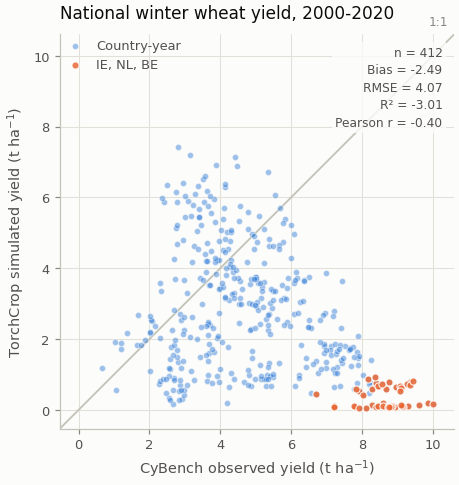

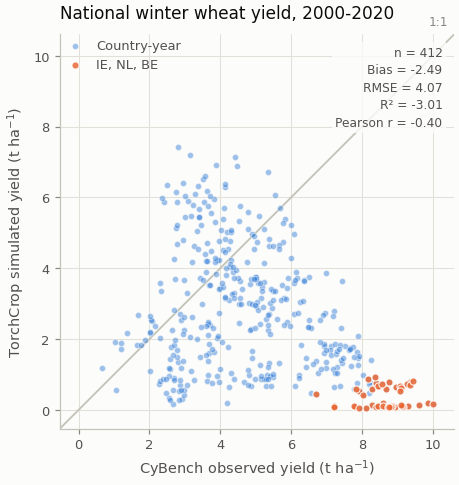

In [11]:
worst = ranked.drop(index="ALL").nsmallest(3, "bias").index.tolist()

fig = plots.scatter_one_to_one(
    paired, "obs_yield", "yield_t_ha", stats=pooled,
    title="National winter wheat yield, 2000-2020",
    xlabel="CyBench observed yield (t ha$^{-1}$)",
    ylabel="TorchCrop simulated yield (t ha$^{-1}$)",
    highlight=worst,
)
plots.save(fig, "yield_01_scatter_one_to_one")
fig

### 8.2 One panel per country

Shared axes across every panel, so a country's distance from the diagonal is
comparable at a glance. Panels are ordered by RMSE, best first.

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/yield_02_scatter_small_multiples(.png/.pdf)


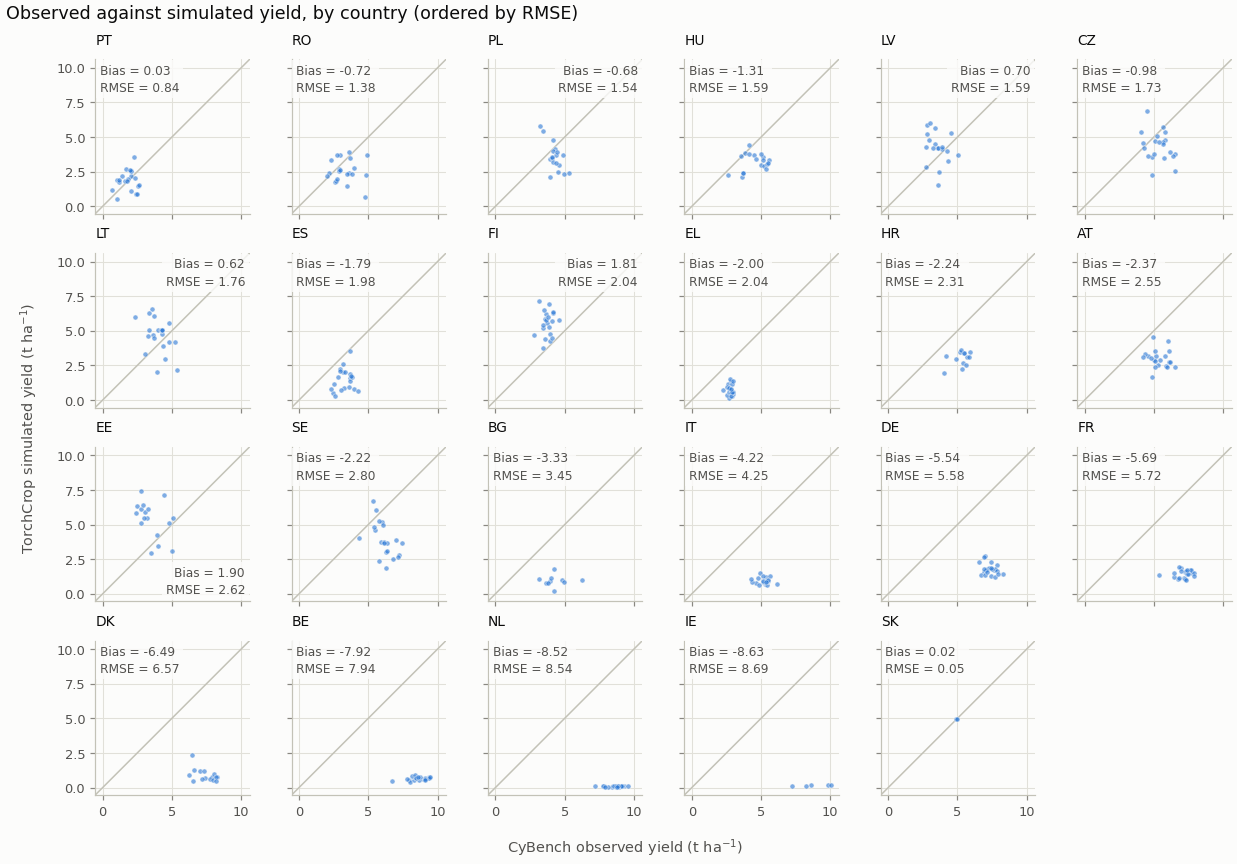

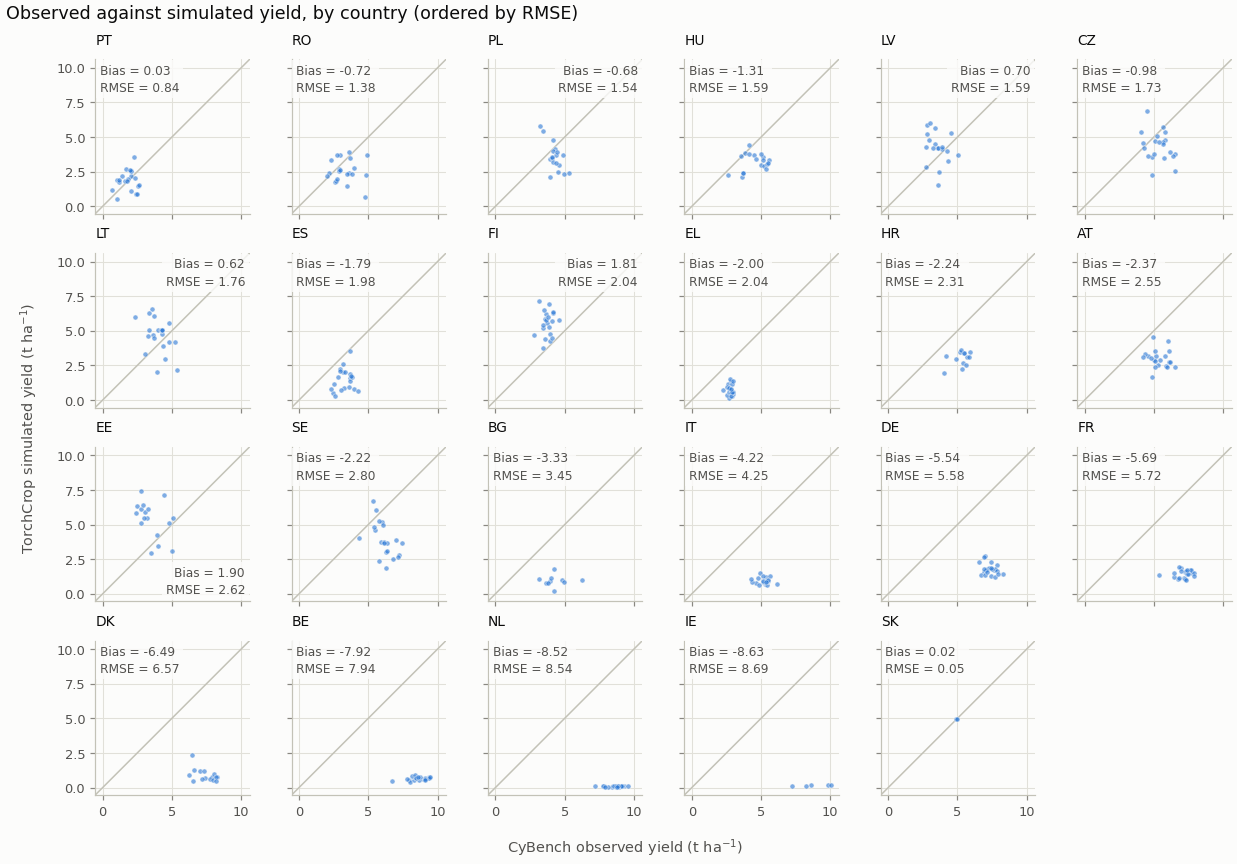

In [12]:
fig = plots.scatter_small_multiples(
    paired, "obs_yield", "yield_t_ha", metrics=by_country,
    order=[c for c in ranked.index if c != "ALL"],
    title="Observed against simulated yield, by country (ordered by RMSE)",
    xlabel="CyBench observed yield (t ha$^{-1}$)",
    ylabel="TorchCrop simulated yield (t ha$^{-1}$)",
)
plots.save(fig, "yield_02_scatter_small_multiples")
fig

### 8.3 Country-wise bias

The fill carries the **sign** only — the bar's length already encodes
magnitude. The whisker is ± RMSE, which is always at least |bias|; where it is
much larger, the country's error is scatter rather than offset.

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/yield_03_bias_by_country(.png/.pdf)


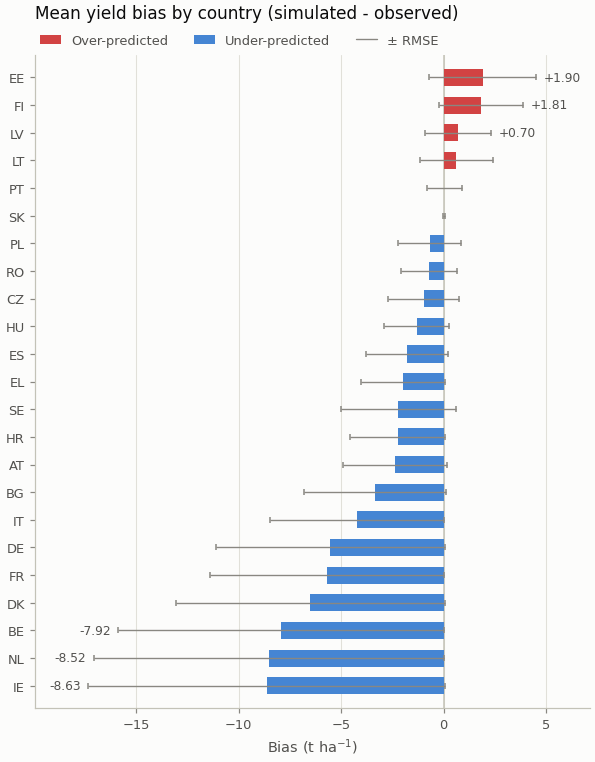

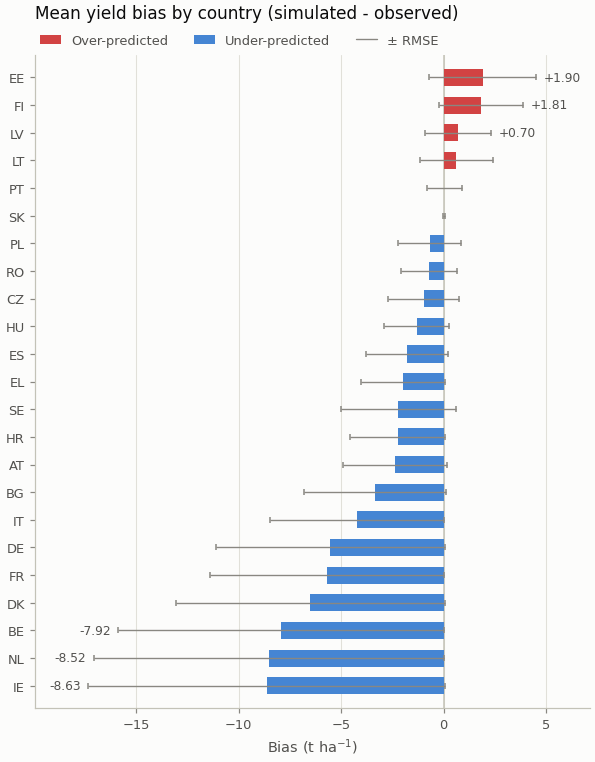

In [13]:
fig = plots.bias_bars(
    ranked, value_col="bias", error_col="rmse",
    title="Mean yield bias by country (simulated - observed)",
    xlabel="Bias (t ha$^{-1}$)",
)
plots.save(fig, "yield_03_bias_by_country")
fig

### 8.4 Residuals

Three views, because they fail differently: against the observation (a slope
error shows as a trend), against time (drift or a bad year), and as a
distribution (shift versus spread).

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/yield_04_residuals(.png/.pdf)


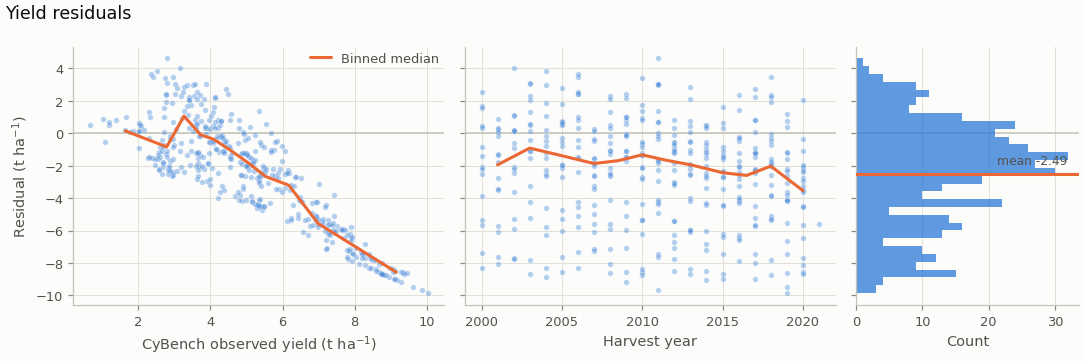

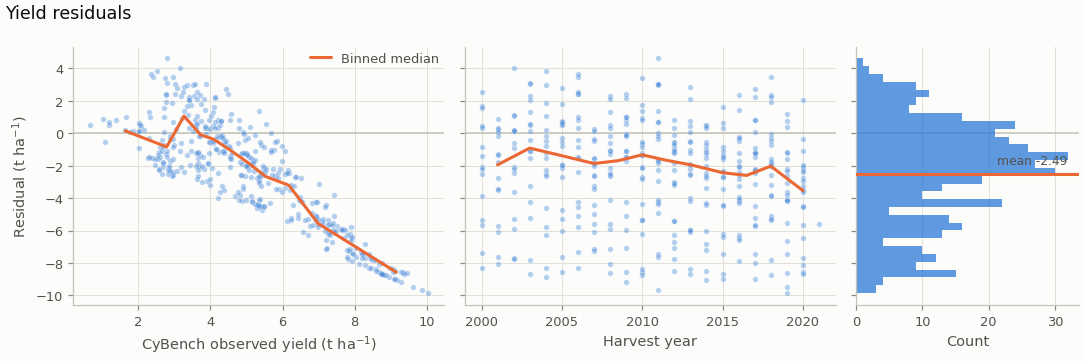

In [14]:
fig = plots.residual_panels(
    paired, "residual", "obs_yield",
    title="Yield residuals",
    ylabel="Residual (t ha$^{-1}$)",
    xlabel_obs="CyBench observed yield (t ha$^{-1}$)",
)
plots.save(fig, "yield_04_residuals")
fig

### 8.5 Time series by country

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/yield_05_timeseries(.png/.pdf)


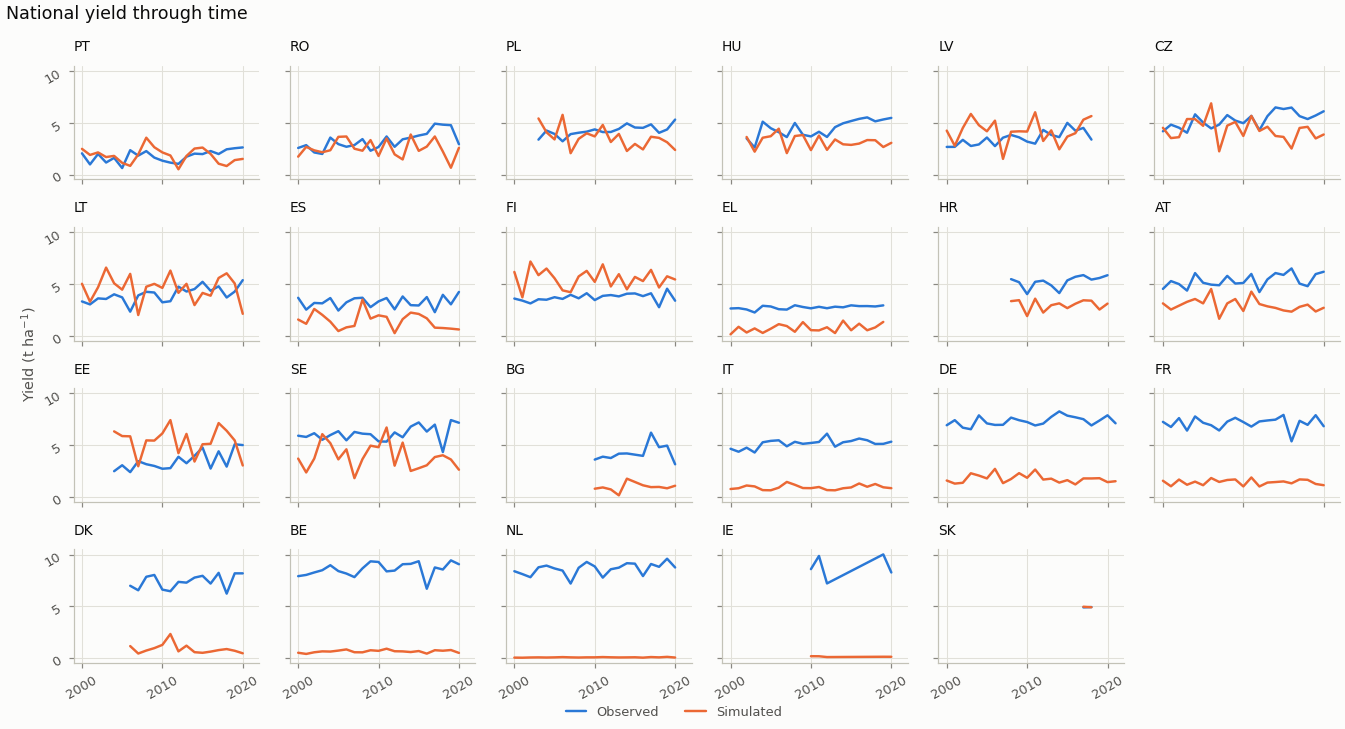

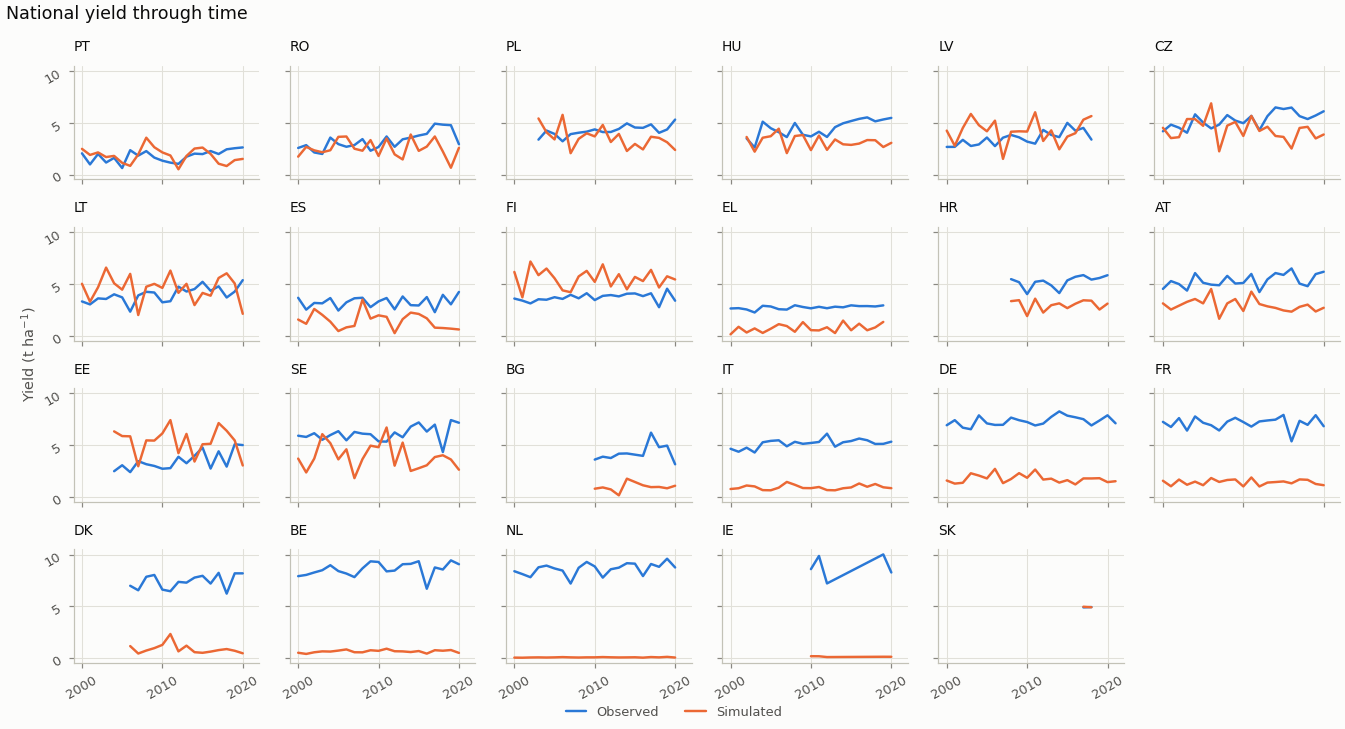

In [15]:
fig = plots.timeseries_small_multiples(
    paired, "obs_yield", "yield_t_ha",
    order=[c for c in ranked.index if c != "ALL"],
    title="National yield through time",
    ylabel="Yield (t ha$^{-1}$)",
)
plots.save(fig, "yield_05_timeseries")
fig

### 8.6 Maps

The native 10 km field first — the country means above are averages over this —
then the country bias.

INFO utils.regions: 946 admin polygons across 23 countries


INFO utils.regions: dissolved to 23 national footprints


INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/yield_06_map_simulated_cells(.png/.pdf)


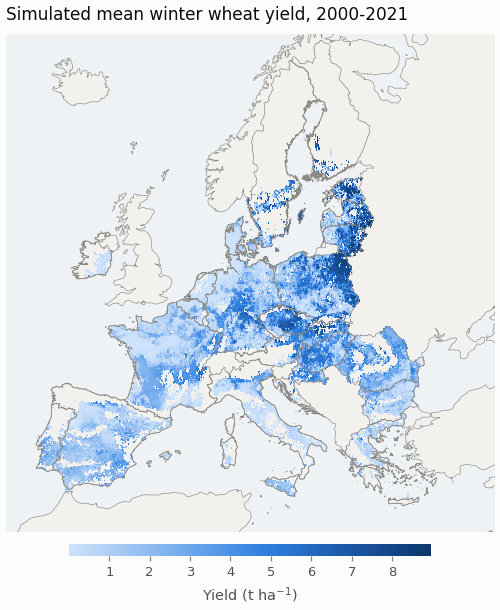

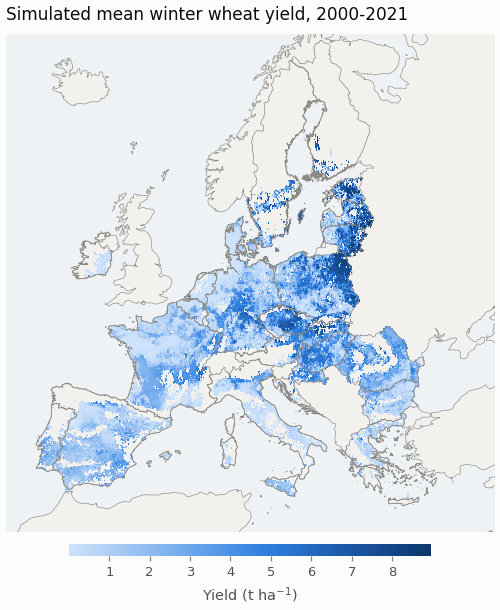

In [16]:
polygons = regions.load_country_polygons(COUNTRIES)

cell_mean = (
    scoped.groupby(["SimplaceID", "lon", "lat"], as_index=False)["yield_t_ha"].mean()
)

fig = plots.cell_map(
    cell_mean, "yield_t_ha",
    title=f"Simulated mean winter wheat yield, {paired['year'].min()}-{paired['year'].max()}",
    cbar_label="Yield (t ha$^{-1}$)", overlay=polygons,
)
plots.save(fig, "yield_06_map_simulated_cells")
fig

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/yield_07_map_bias(.png/.pdf)


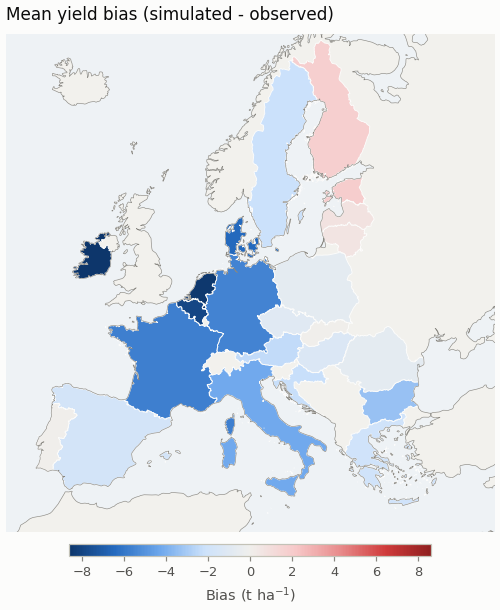

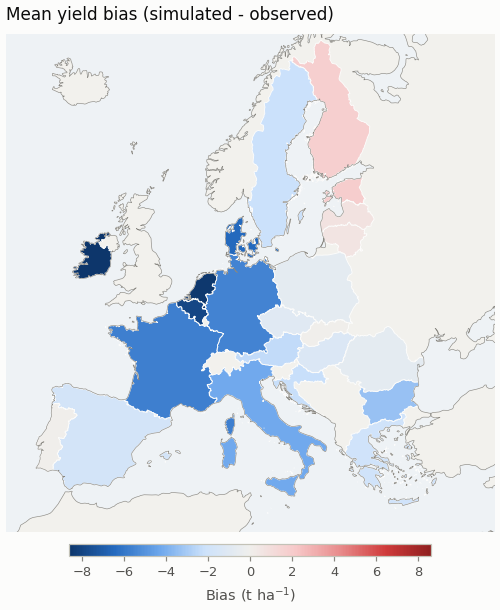

In [17]:
fig = plots.country_choropleth(
    polygons, ranked["bias"],
    title="Mean yield bias (simulated - observed)",
    cbar_label="Bias (t ha$^{-1}$)", diverging=True,
)
plots.save(fig, "yield_07_map_bias")
fig

## 9. Diagnostics — where the failure is, and what it looks like

The bias is not a uniform offset: it is near zero across the Baltic and central
Europe and catastrophic around the North Sea. That pattern is not something the
metrics explain on their own, so this section pulls the run's own state
variables alongside the bias to say what the model is doing in the countries it
gets wrong.

In [18]:
state = (
    scoped.groupby("country")
    .agg(sim_yield=("yield_t_ha", "mean"),
         max_lai=("max_lai", "mean"),
         biomass=("biomass_g_m2", "mean"),
         days_to_maturity=("days_to_maturity", "mean"),
         water_stress=("tranrf_mean", "mean"),
         n_index=("nni_mean", "mean"),
         heat=("heat_stress_factor", "mean"),
         failed_share=("yield_t_ha", lambda s: float((s < 0.5).mean())))
)
state["obs_yield"] = ranked["obs_mean"]
state["bias"] = ranked["bias"]

print("Correlation of country bias with the run's own state variables:")
print(state.corr(numeric_only=True)["bias"].drop("bias").round(2).sort_values().to_string())

state.sort_values("bias").round(3)

Correlation of country bias with the run's own state variables:
failed_share       -0.88
obs_yield          -0.88
n_index            -0.55
days_to_maturity    0.28
heat                0.55
water_stress        0.72
sim_yield           0.84
biomass             0.85
max_lai             0.90


,sim_yield,max_lai,biomass,days_to_maturity,water_stress,n_index,heat,failed_share,obs_yield,bias
country,,,,,,,,,,
IE,0.149,0.388,21.403999,259.247986,0.637,0.994,0.0,0.930,8.796,-8.629
NL,0.093,0.363,15.762000,257.183990,0.499,0.998,0.0,0.960,8.613,-8.518
BE,0.656,0.698,85.056000,256.894012,0.682,0.972,0.0,0.691,8.588,-7.918
DK,0.859,0.562,114.380997,286.334015,0.735,0.960,0.0,0.575,7.401,-6.494
FR,1.435,1.281,186.209000,237.998001,0.790,0.957,0.0,0.381,7.143,-5.692
DE,1.739,0.984,236.242004,274.350006,0.814,0.948,0.0,0.355,7.334,-5.540
IT,0.976,1.438,143.376007,203.470993,0.625,0.986,0.0,0.572,5.180,-4.222
BG,1.003,1.219,148.334000,249.332001,0.717,0.987,0.0,0.539,4.291,-3.334
AT,2.923,1.451,407.718994,273.855011,0.849,0.936,0.0,0.221,5.359,-2.370


`failed_share` is the fraction of cell-seasons yielding under 0.5 t ha⁻¹ — an
effective crop failure. Read it next to `max_lai`: where the simulated canopy
never closes, there is no yield to speak of, and the country's bias is that
failure rather than a calibration offset.

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/yield_08_map_max_lai(.png/.pdf)


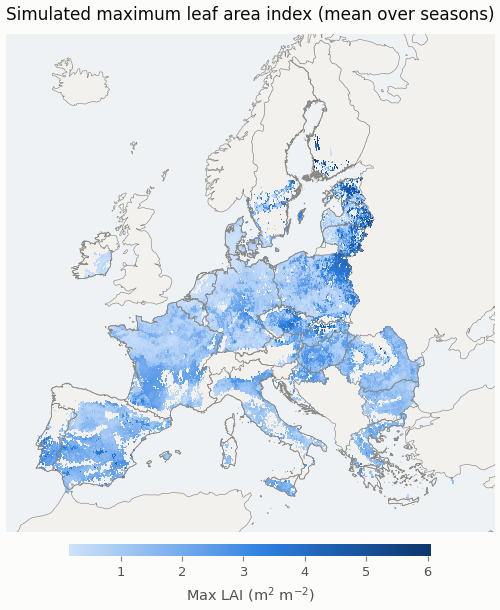

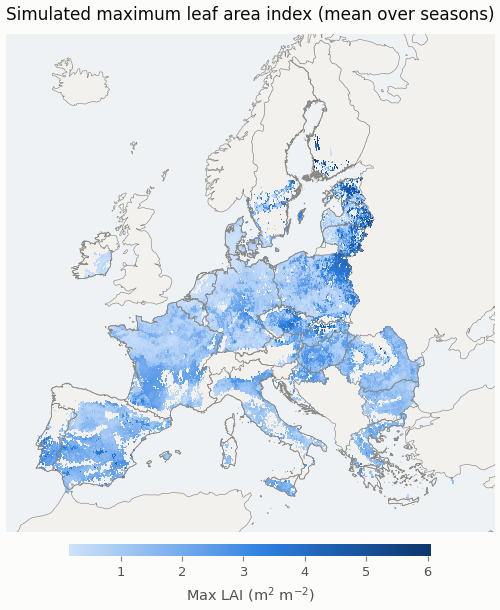

In [19]:
fig = plots.cell_map(
    scoped.groupby(["SimplaceID", "lon", "lat"], as_index=False)["max_lai"].mean(),
    "max_lai",
    title="Simulated maximum leaf area index (mean over seasons)",
    cbar_label="Max LAI (m$^2$ m$^{-2}$)", overlay=polygons,
)
plots.save(fig, "yield_08_map_max_lai")
fig

## 10. Summary

In [20]:
summary = pd.Series({
    "countries": paired["country"].nunique(),
    "country-years": len(paired),
    "years": f"{paired['year'].min()}-{paired['year'].max()}",
    "10 km cells": int(cells["country"].notna().sum()),
    "observed mean (t/ha)": round(pooled["obs_mean"], 2),
    "simulated mean (t/ha)": round(pooled["sim_mean"], 2),
    "bias (t/ha)": round(pooled["bias"], 2),
    "RMSE (t/ha)": round(pooled["rmse"], 2),
    "MAE (t/ha)": round(pooled["mae"], 2),
    "MAPE (%)": round(pooled["mape"], 1),
    "R2": round(pooled["r2"], 2),
    "Pearson r": round(pooled["pearson_r"], 2),
}, name="value")

paired.to_csv(config.TABLE_DIR / "yield_paired_country_year.csv",
              index=False, float_format="%.4f")
state.to_csv(config.TABLE_DIR / "yield_diagnostics_by_country.csv",
             float_format="%.4f")
print(f"tables written to {config.TABLE_DIR}")
print(f"figures written to {config.FIGURE_DIR}")
summary.to_frame()

tables written to /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/tables
figures written to /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures


,value
countries,23
country-years,412
years,2000-2021
10 km cells,30406
observed mean (t/ha),5.08
simulated mean (t/ha),2.59
bias (t/ha),-2.49
RMSE (t/ha),4.07
MAE (t/ha),3.16
MAPE (%),57.0


### What the numbers mean, and what they do not

* **The pooled skill is dominated by a level error, not by noise.** The bias is
  a large share of the RMSE, and the residual trends with the observation — the
  model reproduces less of the high-yielding end than of the low.
* **Part of that offset is a units difference, not model error.** No moisture
  conversion was applied (see the header); the simulated dry matter is expected
  to sit ~13.5 % below a market-moisture statistic before any model error is
  counted. That accounts for a fraction of the offset, not for the countries
  simulating near-total crop failure.
* **The maritime north-west is a distinct failure, not a worse calibration.**
  §9 shows the simulated canopy never developing there, so those countries'
  metrics measure a model failure, not a yield gap. Excluding them changes the
  pooled numbers substantially — quote the per-country table, not the pooled
  row, for anything downstream.
* **The observed side has its own limits.** CyBench's national averages come
  from sub-national statistics with uneven area reporting; `obs_method` records
  where the weighting fell back.